# Trabajo Final - Baseline, optimización de modelos y control de leakage

Este notebook construye un flujo reproducible para preparar el dataset inicial, definir una línea base y buscar un modelo de mejor desempeño mediante `GridSearchCV` con validación cruzada estratificada de 5 folds.

La estrategia metodológica separa los datos en tres conjuntos independientes:

- `train`: se usa para ajustar los modelos y ejecutar la validación cruzada.
- `val`: se usa para comparar el desempeño de los mejores modelos de cada búsqueda.
- `test`: se reserva hasta el final para estimar el desempeño real del modelo seleccionado.

Además, antes de dividir los datos se transforma la variable objetivo con una codificación numérica controlada. Las etiquetas originales del target, por ejemplo `Nivel 1: Insuficiente`, `Nivel 2: Mínimo`, `Nivel 3: Satisfactorio` y `Nivel 4: Avanzado`, se convierten en números usando el número explícito de cada nivel. Así, el código más bajo corresponde a `Nivel 1: Insuficiente` y se conserva el mismo mapeo para `train`, `val` y `test`.

El diseño evita fuga de información (*data leakage*) porque todas las transformaciones de imputación, codificación, escalamiento y entrenamiento se ejecutan dentro de un único `Pipeline` de `scikit-learn`. Por tanto, los parámetros del preprocesamiento se aprenden únicamente con los datos de entrenamiento de cada fold y nunca con validación o test. La codificación del target es una conversión determinística de etiquetas a niveles numéricos y no utiliza variables predictoras ni estadísticas de validación o test.


## 1. Configuración inicial

Se definen rutas, semilla de reproducibilidad y librerías necesarias. Las rutas están configuradas para Google Colab y Google Drive.

In [ ]:
# ============================================================
# 1. Configuración inicial
# ============================================================

import os
import re
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer
)

import joblib

SEED = 42
np.random.seed(SEED)

BASE_DIR = "/content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output"

DATASET_PATH = os.path.join(BASE_DIR, "DataSetInicial.csv")
COLUMNAS_ELIMINAR_PATH = os.path.join(BASE_DIR, "Columas a Eliminar.csv")

TARGET_COL = "target"

# En el dataset completo, déjalo en False. Para pruebas rápidas, cambia a True.
MODO_DESARROLLO = False
N_FILAS_DESARROLLO = 100_000

# Configuración de la partición train/val/test.
TEST_SIZE = 0.20
VAL_SIZE = 0.20
K_FOLDS = 5

print("Ruta dataset:", DATASET_PATH)
print("Ruta columnas a eliminar:", COLUMNAS_ELIMINAR_PATH)
print("K folds:", K_FOLDS)


Ruta dataset: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/DataSetInicial.csv
Ruta columnas a eliminar: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/Columas a Eliminar.csv
K folds: 5


In [ ]:

# 1.1 Métricas multiclase
# Se define f1_macro para obtener una buena metrica en problemas multiclase




METRICA_PRINCIPAL = "f1_macro"


def calcular_metricas_multiclase(y_true, y_pred, prefijo=""):
    """
    Calcula métricas válidas para clasificación multiclase.

    Usa F1 macro como métrica principal porque pondera por igual todas las clases,
    algo importante cuando hay desbalance entre niveles de desempeño.
    """
    p = f"{prefijo}_" if prefijo else ""

    return {
        f"{p}accuracy": accuracy_score(y_true, y_pred),
        f"{p}f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        f"{p}f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }


print("Métrica principal para selección de modelos:", METRICA_PRINCIPAL)


Métrica principal para selección de modelos: f1_macro


## 2. Montar Google Drive

Esta celda monta Google Drive en Colab. Si ya está montado, no hay problema en ejecutarla nuevamente.

In [ ]:
# ============================================================
# 2. Montar Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 3. Carga del dataset y archivo de columnas a eliminar

Se carga el dataset inicial y el archivo `Columas a Eliminar.csv`. También se normalizan los nombres de columnas para evitar problemas por espacios, mayúsculas o caracteres invisibles.

In [ ]:
# ============================================================
# 3. Carga del dataset y columnas a eliminar
# ============================================================

def limpiar_nombre_columnas(df):
    """
    Normaliza nombres de columnas:
    - elimina espacios extremos,
    - elimina caracteres BOM,
    - convierte a minúscula.
    """
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
        .str.lower()
    )
    return df


if MODO_DESARROLLO:
    df = pd.read_csv(
        DATASET_PATH,
        encoding="utf-8-sig",
        low_memory=False,
        nrows=N_FILAS_DESARROLLO
    )
else:
    df = pd.read_csv(
        DATASET_PATH,
        encoding="utf-8-sig",
        low_memory=False
    )

df = limpiar_nombre_columnas(df)

columnas_eliminar_df = pd.read_csv(
    COLUMNAS_ELIMINAR_PATH,
    encoding="utf-8-sig",
    low_memory=False
)

columnas_eliminar_df = limpiar_nombre_columnas(columnas_eliminar_df)

print("Shape dataset inicial:", df.shape)
display(df.head())

print("\nArchivo de columnas a eliminar:")
display(columnas_eliminar_df)

Shape dataset inicial: (566241, 33)


,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_depto_ubicacion,cole_genero,cole_jornada,...,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,target
0,20224,TI,SB11202240536228,URBANO,N,A,TÉCNICO/ACADÉMICO,CAQUETA,MIXTO,UNICA,...,Cuatro,Primaria incompleta,Primaria incompleta,Estrato 2,5 a 6,No,No,No,Si,Nivel 2: Mínimo
1,20224,TI,SB11202240549969,URBANO,N,A,TÉCNICO/ACADÉMICO,QUINDIO,MIXTO,MAÑANA,...,Dos,Educación profesional completa,No Aplica,Estrato 2,3 a 4,No,No,Si,Si,Nivel 2: Mínimo
2,20211,TI,SB11202110001547,RURAL,S,B,ACADÉMICO,CUNDINAMARCA,MIXTO,COMPLETA,...,Tres,Educación profesional completa,Postgrado,Estrato 4,3 a 4,Si,Si,Si,Si,Nivel 3: Satisfactorio
3,20211,CR,SB11202110021004,URBANO,NaN,A,ACADÉMICO,CUNDINAMARCA,MIXTO,MAÑANA,...,Tres,Educación profesional completa,Educación profesional completa,Estrato 5,1 a 2,Si,Si,Si,Si,Nivel 3: Satisfactorio
4,20224,TI,SB11202240101947,RURAL,NaN,A,NO APLICA,ANTIOQUIA,MIXTO,COMPLETA,...,Dos,Primaria incompleta,Primaria incompleta,Estrato 2,3 a 4,No,No,No,No,Nivel 3: Satisfactorio



Archivo de columnas a eliminar:


,columna_a_eliminar
0,cole_area_ubicacion
1,estu_mcpio_presentacion
2,estu_nacionalidad
3,estu_depto_presentacion
4,fami_tieneautomovil
5,cole_depto_ubicacion
6,estu_depto_reside
7,fami_tienelavadora
8,estu_mcpio_reside
9,estu_estudiante


## 4. Validaciones iniciales

Antes del procesamiento se valida que exista la variable objetivo y que el archivo de columnas a eliminar tenga una estructura interpretable.

In [ ]:
# ============================================================
# 4. Validaciones iniciales
# ============================================================

if TARGET_COL not in df.columns:
    raise ValueError(f"No existe la variable objetivo '{TARGET_COL}' en el dataset.")

if columnas_eliminar_df.shape[1] == 1:
    col_lista_eliminar = columnas_eliminar_df.columns[0]
else:
    col_lista_eliminar = "columna_a_eliminar"
    if col_lista_eliminar not in columnas_eliminar_df.columns:
        raise ValueError(
            "El archivo de columnas a eliminar debe tener una columna llamada "
            "'columna_a_eliminar' o una única columna con el listado."
        )

columnas_a_eliminar = (
    columnas_eliminar_df[col_lista_eliminar]
    .dropna()
    .astype(str)
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
    .str.lower()
    .tolist()
)

columnas_a_eliminar = sorted(set(columnas_a_eliminar + ["periodo"]))

print("Variable objetivo:", TARGET_COL)
print("Cantidad de columnas solicitadas para eliminar:", len(columnas_a_eliminar))
print(columnas_a_eliminar)

Variable objetivo: target
Cantidad de columnas solicitadas para eliminar: 15
['cole_area_ubicacion', 'cole_depto_ubicacion', 'cole_sede_principal', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_mcpio_presentacion', 'estu_mcpio_reside', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad', 'fami_tieneautomovil', 'fami_tienelavadora', 'periodo']


## 5. Eliminación de columnas y control de duplicados

Se eliminan las columnas indicadas en el archivo externo y la columna `periodo`.

Como buena práctica, se revisan duplicados por `estu_consecutivo`, ya que esta variable identifica al estudiante. Si existen duplicados, se conserva el primer registro. Después de usarla para depuración, esta columna se excluye del conjunto de predictores para evitar que actúe como identificador de alta cardinalidad.

In [ ]:
# ============================================================
# 5. Eliminación de columnas y duplicados por estu_consecutivo
# ============================================================

columnas_existentes_a_eliminar = [col for col in columnas_a_eliminar if col in df.columns]
columnas_no_encontradas = [col for col in columnas_a_eliminar if col not in df.columns]

df_model = df.drop(columns=columnas_existentes_a_eliminar).copy()

print("Columnas eliminadas efectivamente:", len(columnas_existentes_a_eliminar))
print(columnas_existentes_a_eliminar)

if columnas_no_encontradas:
    print("\nColumnas solicitadas pero no encontradas en el dataset:")
    print(columnas_no_encontradas)

if "estu_consecutivo" in df_model.columns:
    registros_antes = len(df_model)
    duplicados = df_model.duplicated(subset=["estu_consecutivo"], keep=False).sum()

    print(f"\nRegistros involucrados en duplicados por estu_consecutivo: {duplicados:,}")

    df_model = (
        df_model
        .drop_duplicates(subset=["estu_consecutivo"], keep="first")
        .reset_index(drop=True)
    )

    registros_despues = len(df_model)
    print(f"Registros antes: {registros_antes:,}")
    print(f"Registros después de eliminar duplicados: {registros_despues:,}")
    print(f"Registros eliminados: {registros_antes - registros_despues:,}")

print("\nShape después de eliminación de columnas y duplicados:", df_model.shape)
display(df_model.head())

Columnas eliminadas efectivamente: 15
['cole_area_ubicacion', 'cole_depto_ubicacion', 'cole_sede_principal', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_mcpio_presentacion', 'estu_mcpio_reside', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad', 'fami_tieneautomovil', 'fami_tienelavadora', 'periodo']

Registros involucrados en duplicados por estu_consecutivo: 0
Registros antes: 566,241
Registros después de eliminar duplicados: 566,241
Registros eliminados: 0

Shape después de eliminación de columnas y duplicados: (566241, 18)


,estu_tipodocumento,estu_consecutivo,cole_bilingue,cole_calendario,cole_caracter,cole_genero,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,estu_genero,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tienecomputador,fami_tieneinternet,target
0,TI,SB11202240536228,N,A,TÉCNICO/ACADÉMICO,MIXTO,UNICA,EL DONCELLO,OFICIAL,F,Cuatro,Primaria incompleta,Primaria incompleta,Estrato 2,5 a 6,No,No,Nivel 2: Mínimo
1,TI,SB11202240549969,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,ARMENIA,OFICIAL,F,Dos,Educación profesional completa,No Aplica,Estrato 2,3 a 4,No,Si,Nivel 2: Mínimo
2,TI,SB11202110001547,S,B,ACADÉMICO,MIXTO,COMPLETA,SOPÓ,NO OFICIAL,M,Tres,Educación profesional completa,Postgrado,Estrato 4,3 a 4,Si,Si,Nivel 3: Satisfactorio
3,CR,SB11202110021004,NaN,A,ACADÉMICO,MIXTO,MAÑANA,TENJO,NO OFICIAL,M,Tres,Educación profesional completa,Educación profesional completa,Estrato 5,1 a 2,Si,Si,Nivel 3: Satisfactorio
4,TI,SB11202240101947,NaN,A,NO APLICA,MIXTO,COMPLETA,ANDES,OFICIAL,M,Dos,Primaria incompleta,Primaria incompleta,Estrato 2,3 a 4,No,No,Nivel 3: Satisfactorio


## 6. Separación de variables predictoras y variable objetivo

Se separa `X` y la variable objetivo original como `y_texto`. La columna `estu_consecutivo` se elimina de `X` porque es un identificador y no debe usarse para entrenar el modelo.

En la siguiente sección, `y_texto` se transforma a una versión numérica controlada para evitar problemas en modelos que no trabajan adecuadamente con etiquetas de texto como variable objetivo.


In [ ]:
# ============================================================
# 6. Separación X/y original
# ============================================================

# Se eliminan registros sin target, porque no pueden usarse en entrenamiento supervisado.
df_model = df_model.dropna(subset=[TARGET_COL]).reset_index(drop=True)

id_cols_no_modelar = ["estu_consecutivo"]
id_cols_no_modelar = [col for col in id_cols_no_modelar if col in df_model.columns]

X = df_model.drop(columns=[TARGET_COL] + id_cols_no_modelar).copy()
y_texto = (
    df_model[TARGET_COL]
    .astype(str)
    .str.strip()
    .copy()
)

y_texto.name = TARGET_COL

print("Shape X:", X.shape)
print("Shape y_texto:", y_texto.shape)

print("\nDistribución original del target textual:")
display(y_texto.value_counts(dropna=False).to_frame("frecuencia"))
display((y_texto.value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("porcentaje"))


Shape X: (566241, 16)
Shape y_texto: (566241,)

Distribución original del target textual:


,frecuencia
target,
Nivel 2: Mínimo,268741
Nivel 3: Satisfactorio,170346
Nivel 1: Insuficiente,104523
Nivel 4: Avanzado,22631


,porcentaje
target,
Nivel 2: Mínimo,47.46
Nivel 3: Satisfactorio,30.08
Nivel 1: Insuficiente,18.46
Nivel 4: Avanzado,4.00


## 6.1 Codificación numérica del target con `LabelEncoder`

Para evitar errores en modelos que no manejan bien etiquetas textuales, la variable objetivo se transforma antes del split. La codificación conserva la semántica ordinal del nombre de la clase: `Nivel 1` se codifica como `1`, `Nivel 2` como `2`, `Nivel 3` como `3` y `Nivel 4` como `4`.

La coherencia se garantiza creando un único mapeo y aplicándolo a todo el vector objetivo antes de separar `train`, `val` y `test`. Esto no introduce leakage porque no transforma variables predictoras ni usa información estadística de los conjuntos de validación o prueba; solo reemplaza etiquetas por códigos fijos derivados del número explícito del nivel.


In [ ]:
# ============================================================
# 6.1 Codificación numérica del target con LabelEncoder
# ============================================================

# Algunos algoritmos trabajan de forma más estable con targets numéricos.
# En este proyecto, las clases tienen un número explícito en el texto:
# "Nivel 1", "Nivel 2", "Nivel 3", "Nivel 4".
# Por decisión metodológica, el target del modelo usará esos números: 1, 2, 3 y 4.

PATRON_NIVEL_TARGET = re.compile(r"nivel\s*(\d+)", flags=re.IGNORECASE)


def extraer_numero_nivel(etiqueta):
    """
    Extrae el número de nivel desde una etiqueta tipo:
    'Nivel 1: Insuficiente'.
    """
    if pd.isna(etiqueta):
        return np.nan

    etiqueta_str = str(etiqueta).strip()
    match = PATRON_NIVEL_TARGET.search(etiqueta_str)

    if match is None:
        return np.nan

    return int(match.group(1))


# Identificación de clases y ordenamiento por el número real del nivel.
etiquetas_target_unicas = pd.Series(y_texto.unique(), name="etiqueta_original")

mapeo_target = pd.DataFrame({
    "etiqueta_original": etiquetas_target_unicas
})
mapeo_target["nivel_extraido"] = mapeo_target["etiqueta_original"].apply(extraer_numero_nivel)

if mapeo_target["nivel_extraido"].isna().any():
    display(mapeo_target[mapeo_target["nivel_extraido"].isna()])
    raise ValueError(
        "Existen etiquetas del target en las que no fue posible extraer el número de nivel. "
        "Revisa los valores de la variable objetivo antes de continuar."
    )

if mapeo_target["nivel_extraido"].duplicated().any():
    display(mapeo_target.sort_values("nivel_extraido"))
    raise ValueError(
        "Hay más de una etiqueta asociada al mismo número de nivel. "
        "Esto puede indicar inconsistencias en la variable objetivo."
    )

mapeo_target = mapeo_target.sort_values("nivel_extraido").reset_index(drop=True)

# LabelEncoder se inicializa con las clases en el orden metodológico correcto.
# El código propio de LabelEncoder es 0, 1, 2, 3, pero se conserva solo como
# referencia técnica. El target final del modelo usa el número real del nivel: 1, 2, 3 y 4.
target_label_encoder = LabelEncoder()
target_label_encoder.classes_ = mapeo_target["etiqueta_original"].to_numpy(dtype=object)

mapeo_target["codigo_labelencoder_0_based"] = target_label_encoder.transform(
    mapeo_target["etiqueta_original"]
)
mapeo_target["codigo_target_modelo"] = mapeo_target["nivel_extraido"].astype(int)

TARGET_LABELS_ORIGINALES = mapeo_target["etiqueta_original"].tolist()
TARGET_LABELS_CODIFICADOS = mapeo_target["codigo_target_modelo"].tolist()
TARGET_CODIGO_A_ETIQUETA = dict(zip(
    mapeo_target["codigo_target_modelo"],
    mapeo_target["etiqueta_original"]
))
TARGET_ETIQUETA_A_CODIGO = dict(zip(
    mapeo_target["etiqueta_original"],
    mapeo_target["codigo_target_modelo"]
))
N_CLASES_TARGET = len(TARGET_LABELS_CODIFICADOS)

# Transformación final del target: se toma el número explícito de cada nivel.
y = y_texto.map(TARGET_ETIQUETA_A_CODIGO)

if y.isna().any():
    raise ValueError("No fue posible codificar todos los valores de la variable objetivo.")

y = pd.Series(
    y.astype(int),
    index=y_texto.index,
    name=f"{TARGET_COL}_codificado"
)

# Validaciones de coherencia.
assert y.min() == min(TARGET_LABELS_CODIFICADOS), (
    "El menor código del target no coincide con el menor código definido en el mapeo."
)
assert "nivel 1" in TARGET_CODIGO_A_ETIQUETA[min(TARGET_LABELS_CODIFICADOS)].lower(), (
    "El menor código del target no quedó asociado a Nivel 1."
)
assert np.array_equal(
    mapeo_target["codigo_labelencoder_0_based"].to_numpy(),
    np.arange(len(mapeo_target))
), "LabelEncoder no quedó alineado con el orden metodológico del target."


def decodificar_target(y_codificado):
    """
    Convierte códigos numéricos 1..K nuevamente a etiquetas textuales originales.
    """
    y_array = np.asarray(y_codificado).astype(int)

    codigos_no_validos = sorted(set(y_array) - set(TARGET_LABELS_CODIFICADOS))
    if codigos_no_validos:
        raise ValueError(f"Códigos de target no reconocidos: {codigos_no_validos}")

    return pd.Series(y_array).map(TARGET_CODIGO_A_ETIQUETA).to_numpy()


print("Mapeo final del target usado por todos los modelos:")
display(mapeo_target[[
    "codigo_target_modelo",
    "etiqueta_original",
    "nivel_extraido",
    "codigo_labelencoder_0_based"
]])

print("\nDistribución del target codificado:")
distribucion_y = (
    y.value_counts()
    .sort_index()
    .rename("frecuencia")
    .to_frame()
    .rename_axis("codigo_target_modelo")
    .reset_index()
)
distribucion_y["etiqueta_original"] = distribucion_y["codigo_target_modelo"].map(TARGET_CODIGO_A_ETIQUETA)
display(distribucion_y[["codigo_target_modelo", "etiqueta_original", "frecuencia"]])

print("\nValidación de correspondencia código ↔ etiqueta:")
validacion_mapeo = pd.DataFrame({
    "codigo_target_modelo": TARGET_LABELS_CODIFICADOS,
    "etiqueta_decodificada": decodificar_target(TARGET_LABELS_CODIFICADOS)
})
display(validacion_mapeo)

print("Codificación validada: el menor código corresponde a Nivel 1 y el target es numérico.")


Mapeo final del target usado por todos los modelos:


,codigo_target_modelo,etiqueta_original,nivel_extraido,codigo_labelencoder_0_based
0,1,Nivel 1: Insuficiente,1,0
1,2,Nivel 2: Mínimo,2,1
2,3,Nivel 3: Satisfactorio,3,2
3,4,Nivel 4: Avanzado,4,3



Distribución del target codificado:


,codigo_target_modelo,etiqueta_original,frecuencia
0,1,Nivel 1: Insuficiente,104523
1,2,Nivel 2: Mínimo,268741
2,3,Nivel 3: Satisfactorio,170346
3,4,Nivel 4: Avanzado,22631



Validación de correspondencia código ↔ etiqueta:


,codigo_target_modelo,etiqueta_decodificada
0,1,Nivel 1: Insuficiente
1,2,Nivel 2: Mínimo
2,3,Nivel 3: Satisfactorio
3,4,Nivel 4: Avanzado


Codificación validada: el menor código corresponde a Nivel 1 y el target es numérico.


## 8. División train/validación/test

Se separa el dataset en tres conjuntos mutuamente excluyentes. Primero se reserva `test`, que no será usado durante la búsqueda de hiperparámetros. Luego, a partir del remanente, se separa `train` y `val`.

Con `TEST_SIZE = 0.20` y `VAL_SIZE = 0.20`, la distribución final aproximada es:

- 60 % entrenamiento.
- 20 % validación.
- 20 % prueba final.

La estratificación conserva la proporción de clases en cada subconjunto, lo cual es importante porque el problema es de clasificación multiclase.

In [ ]:
# ============================================================
# 8. Train/validation/test split
# ============================================================

min_clase = y.value_counts().min()
if min_clase < K_FOLDS:
    raise ValueError(
        f"La clase minoritaria tiene {min_clase} registros. "
        f"No es metodológicamente seguro ejecutar StratifiedKFold con {K_FOLDS} folds."
    )

stratify_y = y

# 1) Reserva final de test.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=stratify_y
)

# 2) Separación de validación desde el remanente.
val_size_relativo = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_size_relativo,
    random_state=SEED,
    stratify=y_train_val
)

# Validación explícita: todos los splits conservan la misma codificación numérica del target.
for nombre_split, y_split in {
    "train": y_train,
    "val": y_val,
    "test": y_test,
    "train_val": y_train_val
}.items():
    codigos_presentes = sorted(pd.Series(y_split).unique().tolist())
    codigos_no_validos = sorted(set(codigos_presentes) - set(TARGET_LABELS_CODIFICADOS))

    if codigos_no_validos:
        raise ValueError(
            f"El split {nombre_split} contiene códigos de target no reconocidos: {codigos_no_validos}"
        )

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

resumen_splits = pd.DataFrame({
    "dataset": ["train", "val", "test"],
    "registros": [len(X_train), len(X_val), len(X_test)],
    "porcentaje": [
        len(X_train) / len(X),
        len(X_val) / len(X),
        len(X_test) / len(X)
    ]
})
resumen_splits["porcentaje"] = (resumen_splits["porcentaje"] * 100).round(2)
display(resumen_splits)

print("\nDistribución porcentual del target codificado por split:")
dist_target_splits = pd.concat([
    (y_train.value_counts(normalize=True).sort_index() * 100).rename("train"),
    (y_val.value_counts(normalize=True).sort_index() * 100).rename("val"),
    (y_test.value_counts(normalize=True).sort_index() * 100).rename("test")
], axis=1).fillna(0).round(2)

dist_target_splits = (
    dist_target_splits
    .rename_axis("codigo_target_modelo")
    .reset_index()
)
dist_target_splits["etiqueta_original"] = dist_target_splits["codigo_target_modelo"].map(TARGET_CODIGO_A_ETIQUETA)
dist_target_splits = dist_target_splits[["codigo_target_modelo", "etiqueta_original", "train", "val", "test"]]
display(dist_target_splits)

print("\nValidación de codificación en los tres splits:")
for codigo in TARGET_LABELS_CODIFICADOS:
    print(f"{codigo} -> {TARGET_CODIGO_A_ETIQUETA[codigo]}")


X_train: (339744, 16)
X_val: (113248, 16)
X_test: (113249, 16)
y_train: (339744,)
y_val: (113248,)
y_test: (113249,)


,dataset,registros,porcentaje
0,train,339744,60.0
1,val,113248,20.0
2,test,113249,20.0



Distribución porcentual del target codificado por split:


,codigo_target_modelo,etiqueta_original,train,val,test
0,1,Nivel 1: Insuficiente,18.46,18.46,18.46
1,2,Nivel 2: Mínimo,47.46,47.46,47.46
2,3,Nivel 3: Satisfactorio,30.08,30.08,30.08
3,4,Nivel 4: Avanzado,4.00,4.00,4.00



Validación de codificación en los tres splits:
1 -> Nivel 1: Insuficiente
2 -> Nivel 2: Mínimo
3 -> Nivel 3: Satisfactorio
4 -> Nivel 4: Avanzado


## 9. Transformadores personalizados

Se realiza engineering feature. Estos transformadores hacen parte del `Pipeline`, por lo que se aplican dentro de cada fold de validación cruzada y no antes de dividir los datos.

In [ ]:
# ============================================================
# 9. Transformadores personalizados
# ============================================================

class CrearMayorEdad(BaseEstimator, TransformerMixin):
    """
    Crea la columna 'Mayor edad' a partir de 'estu_tipodocumento':
    - CC -> mayor de edad
    - TI -> Menor de edad
    - Otro valor -> No definido
    Luego elimina 'estu_tipodocumento'.
    """

    def __init__(self, columna_documento="estu_tipodocumento", nueva_columna="Mayor edad"):
        self.columna_documento = columna_documento
        self.nueva_columna = nueva_columna

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if self.columna_documento in X.columns:
            doc = (
                X[self.columna_documento]
                .astype("object")
                .fillna("NO DEFINIDO")
                .astype(str)
                .str.strip()
                .str.upper()
            )

            X[self.nueva_columna] = np.select(
                [doc.eq("CC"), doc.eq("TI")],
                ["mayor de edad", "Menor de edad"],
                default="No definido"
            )

            X = X.drop(columns=[self.columna_documento])

        return X


class AgruparCategorias(BaseEstimator, TransformerMixin):
    """
    Agrupa categorías específicas según reglas de negocio.
    """

    def __init__(self):
        self.mapa_educacion = {
            "Secundaria (Bachillerato) completa": "Secundaria",
            "Primaria incompleta": "Ninguna",
            "Secundaria (Bachillerato) incompleta": "Primaria",
            "Educación profesional completa": "Profesional",
            "Primaria completa": "Primaria",
            "No sabe": "Ninguna",
            "Técnica o tecnológica completa": "Tecnico",
            "Ninguno": "Ninguna",
            "Postgrado": "Postgrado",
            "Técnica o tecnológica incompleta": "Secundaria",
            "Educación profesional incompleta": "Secundaria",
            "No Aplica": "Ninguna"
        }

        self.mapa_municipio = {
            "BOGOTÁ D.C.": "Principal",
            "MEDELLÍN": "Principal",
            "CALI": "Principal",
            "BARRANQUILLA": "Intermedia",
            "CARTAGENA DE INDIAS": "Intermedia",
            "CÚCUTA": "Intermedia",
            "SOACHA": "Intermedia",
            "SOLEDAD": "Pequeña",
            "IBAGUÉ": "Pequeña",
            "SANTA MARTA": "Pequeña",
            "BUCARAMANGA": "Pequeña",
            "VILLAVICENCIO": "Pequeña"
        }

    def fit(self, X, y=None):
        return self

    @staticmethod
    def _mapear_serie(serie, mapa, default_original=True, valor_nulo=None, default_no_mapeado=None):
        s = serie.copy()

        if valor_nulo is not None:
            s = s.astype("object").fillna(valor_nulo)

        s_str = s.astype(str).str.strip()
        resultado = s_str.map(mapa)

        if default_no_mapeado is not None:
            resultado = resultado.fillna(default_no_mapeado)
        elif default_original:
            resultado = resultado.fillna(s_str)

        return resultado

    def transform(self, X):
        X = X.copy()

        for col in ["fami_educacionpadre", "fami_educacionmadre"]:
            if col in X.columns:
                X[col] = self._mapear_serie(
                    X[col],
                    self.mapa_educacion,
                    valor_nulo="Ninguna",
                    default_original=True
                )

        if "cole_mcpio_ubicacion" in X.columns:
            X["cole_mcpio_ubicacion"] = self._mapear_serie(
                X["cole_mcpio_ubicacion"],
                self.mapa_municipio,
                valor_nulo="Otra",
                default_original=False,
                default_no_mapeado="Otra"
            )

        return X


class XGBMulticlassLabelEncoder(BaseEstimator, ClassifierMixin):
    """
    Envoltorio para XGBClassifier cuando el target externo está codificado como 1..K.

    Para conservar la interpretación del proyecto, el target general del notebook usa
    el número real de cada nivel: Nivel 1 -> 1, Nivel 2 -> 2, etc.
    XGBoost suele requerir clases internas consecutivas desde 0.
    Esta clase hace esa conversión solo dentro de XGBoost y devuelve nuevamente
    predicciones en el mismo código 1..K usado por train, val y test.
    """

    def __init__(
        self,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.reg_lambda = reg_lambda
        self.tree_method = tree_method
        self.random_state = random_state
        self.n_jobs = n_jobs

    def fit(self, X, y):
        from xgboost import XGBClassifier

        self.label_encoder_ = LabelEncoder()
        y_encoded = self.label_encoder_.fit_transform(y)
        self.classes_ = self.label_encoder_.classes_

        self.model_ = XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            num_class=len(self.classes_),
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            learning_rate=self.learning_rate,
            subsample=self.subsample,
            colsample_bytree=self.colsample_bytree,
            reg_lambda=self.reg_lambda,
            tree_method=self.tree_method,
            random_state=self.random_state,
            n_jobs=self.n_jobs
        )
        self.model_.fit(X, y_encoded)
        return self

    def predict(self, X):
        y_pred_encoded = self.model_.predict(X).astype(int)
        return self.label_encoder_.inverse_transform(y_pred_encoded)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


## 10. Definición de columnas para el preprocesamiento

Se definen columnas ordinales, nominales y numéricas usando exclusivamente la estructura de `X_train`. Esto evita que el conjunto de validación o test determine qué variables se codifican o escalan.

In [ ]:
# ============================================================
# 10. Definición de columnas para el preprocesamiento
# ============================================================

ordinal_cols = [
    "fami_estratovivienda",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_cuartoshogar",
    "fami_personashogar"
]

ordinal_cols = [col for col in ordinal_cols if col in X_train.columns]

categorical_cols_originales = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

nominal_cols = [
    col for col in categorical_cols_originales
    if col not in ordinal_cols and col != "estu_tipodocumento"
]

if "estu_tipodocumento" in X_train.columns:
    nominal_cols = nominal_cols + ["Mayor edad"]

nominal_cols = list(dict.fromkeys(nominal_cols))

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [
    col for col in numeric_cols
    if col not in ordinal_cols and col != "estu_tipodocumento"
]

print("Columnas ordinales:", ordinal_cols)
print("Columnas nominales:", nominal_cols)
print("Columnas numéricas:", numeric_cols)


Columnas ordinales: ['fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_cuartoshogar', 'fami_personashogar']
Columnas nominales: ['cole_bilingue', 'cole_calendario', 'cole_caracter', 'cole_genero', 'cole_jornada', 'cole_mcpio_ubicacion', 'cole_naturaleza', 'estu_genero', 'fami_tienecomputador', 'fami_tieneinternet', 'Mayor edad']
Columnas numéricas: []


## 11. Pipeline de preprocesamiento

El preprocesamiento queda encapsulado en un `ColumnTransformer` y luego se integra con cada clasificador dentro de un `Pipeline` completo. Esta es la pieza central para evitar leakage durante `GridSearchCV`, porque en cada fold se ajustan imputadores, codificadores y escaladores únicamente con el subconjunto de entrenamiento del fold.

In [ ]:
# ============================================================
# 11. Pipeline de preprocesamiento
# ============================================================

categorias_ordinales = []

for col in ordinal_cols:
    if col == "fami_estratovivienda":
        categorias_ordinales.append([
            "Sin Estrato",
            "Estrato 1",
            "Estrato 2",
            "Estrato 3",
            "Estrato 4",
            "Estrato 5",
            "Estrato 6"
        ])

    elif col in ["fami_educacionmadre", "fami_educacionpadre"]:
        categorias_ordinales.append([
            "Ninguna",
            "Primaria",
            "Secundaria",
            "Tecnico",
            "Profesional",
            "Postgrado"
        ])

    elif col == "fami_cuartoshogar":
        categorias_ordinales.append([
            "Uno",
            "Dos",
            "Tres",
            "Cuatro",
            "Cinco",
            "Seis o mas"
        ])

    elif col == "fami_personashogar":
        categorias_ordinales.append([
            "1 a 2",
            "3 a 4",
            "5 a 6",
            "7 a 8",
            "9 o más"
        ])

ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal_encoder", OrdinalEncoder(
        categories=categorias_ordinales,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )),
    ("scaler", StandardScaler())
])

nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot_encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformers = []

if len(ordinal_cols) > 0:
    transformers.append(("ordinal", ordinal_pipeline, ordinal_cols))

if len(nominal_cols) > 0:
    transformers.append(("nominal", nominal_pipeline, nominal_cols))

if len(numeric_cols) > 0:
    transformers.append(("numeric", numeric_pipeline, numeric_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.3
)

preprocessor


ColumnTransformer(transformers=[('ordinal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['Sin '
                                                                              'Estrato',
                                                                              'Estrato '
                                                                              '1',
                                                                              'Estrato '
                                                                              '2',
                                                                              'Estrato '
                                                                              '3',
                                                                              'Estrato '
                                                                              '4',
                                                                              'Estrato '
                                                                              '5',
                                                                              'Estrato '
                                                                              '6'],
                                                                             ['Ninguna',
                                                                              'Primaria',
                                                                              'Secundaria',
                                                                              'Tecnico',
                                                                              'Profesional',
                                                                              'Postgrado'],
                                                                             ['Ninguna',
                                                                              'Primaria',
                                                                              'Sec...
                                  'fami_personashogar']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['cole_bilingue', 'cole_calendario',
                                  'cole_caracter', 'cole_genero',
                                  'cole_jornada', 'cole_mcpio_ubicacion',
                                  'cole_naturaleza', 'estu_genero',
                                  'fami_tienecomputador', 'fami_tieneinternet',
                                  'Mayor edad'])])

## 12. Modelo baseline: Regresión Logística One-vs-One

El baseline se mantiene como punto de comparación. Se entrena únicamente con `train` y se evalúa inicialmente en `val`, no en `test`. El conjunto de prueba queda reservado para el modelo seleccionado al final.

In [ ]:
# ============================================================
# 12. Pipeline completo baseline: preprocesamiento + modelo
# ============================================================

log_reg_base = LogisticRegression(
    solver="saga",
    penalty="l2",
    C=1.0,
    max_iter=500,
    tol=1e-3,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

ovo_log_reg = OneVsOneClassifier(
    estimator=log_reg_base,
    n_jobs=-1
)

modelo_baseline = Pipeline(steps=[
    ("feature_engineering", CrearMayorEdad()),
    ("agrupacion_categorias", AgruparCategorias()),
    ("preprocessor", preprocessor),
    ("classifier", ovo_log_reg)
])

modelo_baseline.fit(X_train, y_train)

y_pred_baseline_val = modelo_baseline.predict(X_val)

metricas_baseline_val = {
    "modelo": "Baseline Regresión Logística One-vs-One",
    "tipo_busqueda": "baseline_sin_gridsearch",
    "cv_best_f1_macro": np.nan,
    **calcular_metricas_multiclase(y_val, y_pred_baseline_val, prefijo="val"),
    "best_params": "{}",
    "tiempo_segundos": np.nan
}

print("Métricas baseline en VALIDACIÓN")
print("-" * 60)
for k, v in metricas_baseline_val.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("\nReporte de clasificación baseline en VALIDACIÓN:")
print(classification_report(
    y_val,
    y_pred_baseline_val,
    labels=TARGET_LABELS_CODIFICADOS,
    target_names=TARGET_LABELS_ORIGINALES,
    zero_division=0
))


Métricas baseline en VALIDACIÓN
------------------------------------------------------------
modelo: Baseline Regresión Logística One-vs-One
tipo_busqueda: baseline_sin_gridsearch
cv_best_f1_macro: nan
val_accuracy: 0.3948
val_f1_macro: 0.3754
val_f1_weighted: 0.3997
best_params: {}
tiempo_segundos: nan

Reporte de clasificación baseline en VALIDACIÓN:
                        precision    recall  f1-score   support

 Nivel 1: Insuficiente       0.35      0.60      0.44     20905
       Nivel 2: Mínimo       0.56      0.32      0.41     53748
Nivel 3: Satisfactorio       0.41      0.35      0.38     34069
     Nivel 4: Avanzado       0.17      0.68      0.27      4526

              accuracy                           0.39    113248
             macro avg       0.37      0.49      0.38    113248
          weighted avg       0.46      0.39      0.40    113248



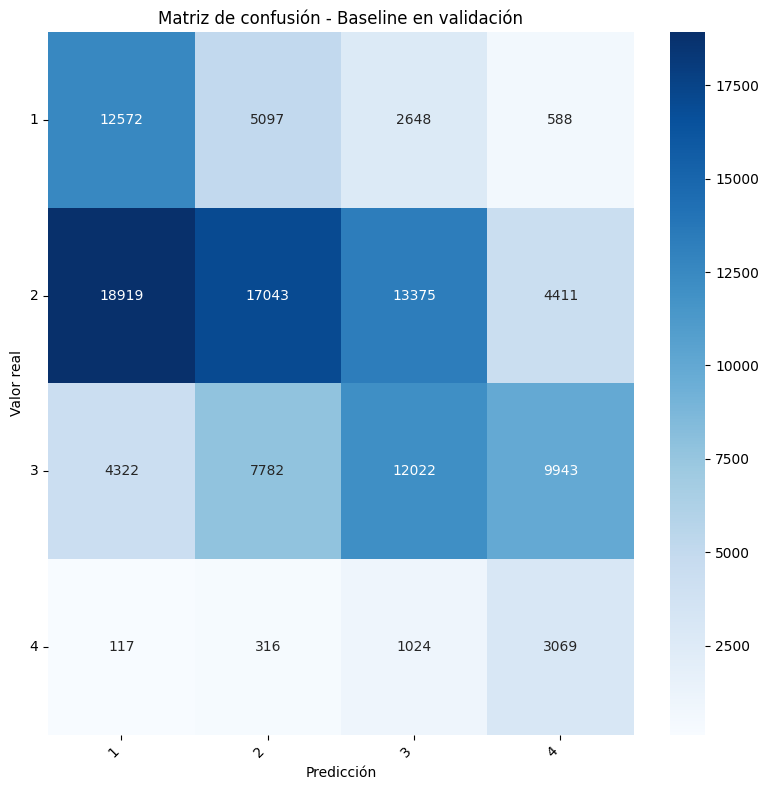

In [ ]:
# ============================================================
# 12.1 Matriz de confusión baseline en validación
# ============================================================

clases_val = sorted(pd.Series(y_val).unique())

cm_baseline_val = confusion_matrix(
    y_val,
    y_pred_baseline_val,
    labels=clases_val
)

tam_fig = max(8, min(14, 0.8 * len(clases_val)))
plt.figure(figsize=(tam_fig, tam_fig))

sns.heatmap(
    cm_baseline_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases_val,
    yticklabels=clases_val
)

plt.title("Matriz de confusión - Baseline en validación")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 13. Instalación e importación de modelos adicionales

Se incorporan los clasificadores: KNN, SVM, árbol de decisión, Random Forest, CatBoost y XGBoost.

Para SVM se usa `LinearSVC`, una formulación SVM más adecuada para datasets grandes y matrices dispersas generadas por `OneHotEncoder`. Esto mantiene el enfoque de SVM, pero evita el costo computacional elevado de un `SVC` con kernel RBF sobre cientos de miles de registros.

In [ ]:
# ============================================================
# 13. Instalación/importación de CatBoost y XGBoost si hace falta
# ============================================================

import importlib.util
import subprocess
import sys

paquetes_requeridos = {
    "catboost": "catboost",
    "xgboost": "xgboost"
}

for paquete_pip, modulo_import in paquetes_requeridos.items():
    if importlib.util.find_spec(modulo_import) is None:
        print(f"Instalando {paquete_pip}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", paquete_pip])

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

print("CatBoost y XGBoost disponibles.")


Instalando catboost...
CatBoost y XGBoost disponibles.


## 14. Configuración de GridSearchCV con validación cruzada de 5 folds

La búsqueda se realiza con `GridSearchCV`, `StratifiedKFold` y métrica principal `F1 macro`, adecuada para clasificación multiclase cuando interesa evaluar el desempeño promedio por clase.

En esta etapa todos los modelos reciben el target ya codificado numéricamente como `1`, `2`, `3` y `4`, preservando la correspondencia con `Nivel 1`, `Nivel 2`, `Nivel 3` y `Nivel 4`. Para XGBoost se conserva un envoltorio interno que convierte temporalmente esos códigos a `0..K-1`, únicamente porque ese algoritmo suele requerir clases consecutivas desde cero.

Para hacer viable la ejecución en Colab sobre datasets grandes, se deja una opción de muestreo estratificado para la búsqueda de hiperparámetros. El modelo final seleccionado se reentrena posteriormente con `train + val` completos antes de evaluar en `test`.


In [ ]:
# ============================================================
# 14. Configuración de GridSearchCV
# ============================================================

# Cambia a False si quieres ejecutar la búsqueda completa sobre todo X_train.
# Para datasets grandes, True evita tiempos excesivos en KNN, SVM, CatBoost y XGBoost.
USAR_MUESTRA_OPTIMIZACION = True
MAX_FILAS_GRIDSEARCH = 120_000

if USAR_MUESTRA_OPTIMIZACION and len(X_train) > MAX_FILAS_GRIDSEARCH:
    X_train_gs, _, y_train_gs, _ = train_test_split(
        X_train,
        y_train,
        train_size=MAX_FILAS_GRIDSEARCH,
        random_state=SEED,
        stratify=y_train
    )
    print("GridSearchCV se ejecutará sobre una muestra estratificada de entrenamiento.")
else:
    X_train_gs = X_train.copy()
    y_train_gs = y_train.copy()
    print("GridSearchCV se ejecutará sobre todo el conjunto de entrenamiento.")

print("X_train usado en GridSearchCV:", X_train_gs.shape)
print("y_train usado en GridSearchCV:", y_train_gs.shape)

if y_train_gs.value_counts().min() < K_FOLDS:
    raise ValueError(
        "Después del muestreo, alguna clase quedó con menos registros que K_FOLDS. "
        "Aumenta MAX_FILAS_GRIDSEARCH o desactiva USAR_MUESTRA_OPTIMIZACION."
    )

cv = StratifiedKFold(
    n_splits=K_FOLDS,
    shuffle=True,
    random_state=SEED
)

# En GridSearchCV usamos directamente "f1_macro".
# No usar "f1", porque "f1" es binario por defecto y genera:
# ValueError: pos_label=1 is not a valid label.
scoring_f1_macro = METRICA_PRINCIPAL

MODELOS_A_EJECUTAR = [
    "knn",
    "svm_lineal",
    "decision_tree",
    "random_forest",
    "catboost",
    "xgboost"
]

print("Modelos configurados para ejecutar:", MODELOS_A_EJECUTAR)


GridSearchCV se ejecutará sobre una muestra estratificada de entrenamiento.
X_train usado en GridSearchCV: (120000, 16)
y_train usado en GridSearchCV: (120000,)
Modelos configurados para ejecutar: ['knn', 'svm_lineal', 'decision_tree', 'random_forest', 'catboost', 'xgboost']


In [ ]:
# ============================================================
# 14.1 Definición de modelos e hiperparámetros
# ============================================================

modelos_grid = {
    "knn": {
        "nombre_largo": "KNN Classifier",
        "estimator": KNeighborsClassifier(n_jobs=-1),
        "param_grid": {
            "classifier__n_neighbors": [5, 11, 21],
            "classifier__weights": ["uniform", "distance"],
            "classifier__metric": ["euclidean", "manhattan"]
        },
        "n_jobs_grid": -1
    },

    "svm_lineal": {
        "nombre_largo": "SVM lineal - LinearSVC",
        "estimator": LinearSVC(
            class_weight="balanced",
            random_state=SEED,
            max_iter=5000,
            dual=False
        ),
        "param_grid": {
            "classifier__C": [0.1, 1.0, 10.0]
        },
        "n_jobs_grid": -1
    },

    "decision_tree": {
        "nombre_largo": "Decision Tree Classifier",
        "estimator": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=SEED
        ),
        "param_grid": {
            "classifier__criterion": ["gini", "entropy"],
            "classifier__max_depth": [10, 20, None],
            "classifier__min_samples_leaf": [1, 10, 30]
        },
        "n_jobs_grid": -1
    },

    "random_forest": {
        "nombre_largo": "Random Forest Classifier",
        "estimator": RandomForestClassifier(
            random_state=SEED,
            class_weight="balanced_subsample",
            n_jobs=-1
        ),
        "param_grid": {
            "classifier__n_estimators": [200, 400],
            "classifier__max_depth": [20, None],
            "classifier__min_samples_leaf": [1, 10],
            "classifier__max_features": ["sqrt"]
        },
        "n_jobs_grid": 1
    },

    "catboost": {
        "nombre_largo": "CatBoost Classifier",
        "estimator": CatBoostClassifier(
            loss_function="MultiClass",
            eval_metric="TotalF1",
            auto_class_weights="Balanced",
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1
        ),
        "param_grid": {
            "classifier__iterations": [200, 500],
            "classifier__depth": [4, 6],
            "classifier__learning_rate": [0.05, 0.10],
            "classifier__l2_leaf_reg": [3]
        },
        "n_jobs_grid": 1
    },

    "xgboost": {
        "nombre_largo": "XGBoost Classifier",
        "estimator": XGBMulticlassLabelEncoder(
            random_state=SEED,
            n_jobs=-1
        ),
        "param_grid": {
            "classifier__n_estimators": [200, 400],
            "classifier__max_depth": [3, 5],
            "classifier__learning_rate": [0.05, 0.10],
            "classifier__subsample": [0.8],
            "classifier__colsample_bytree": [0.8],
            "classifier__reg_lambda": [1.0]
        },
        "n_jobs_grid": 1
    }
}

# Validación para evitar errores por nombres mal escritos.
modelos_no_definidos = [m for m in MODELOS_A_EJECUTAR if m not in modelos_grid]
if modelos_no_definidos:
    raise ValueError(f"Modelos no definidos en modelos_grid: {modelos_no_definidos}")

for clave in MODELOS_A_EJECUTAR:
    n_combinaciones = 1
    for valores in modelos_grid[clave]["param_grid"].values():
        n_combinaciones *= len(valores)
    print(f"{clave}: {n_combinaciones} combinaciones x {K_FOLDS} folds = {n_combinaciones * K_FOLDS} ajustes")


knn: 12 combinaciones x 5 folds = 60 ajustes
svm_lineal: 3 combinaciones x 5 folds = 15 ajustes
decision_tree: 18 combinaciones x 5 folds = 90 ajustes
random_forest: 8 combinaciones x 5 folds = 40 ajustes
catboost: 8 combinaciones x 5 folds = 40 ajustes
xgboost: 8 combinaciones x 5 folds = 40 ajustes


## 15. Ejecución de GridSearchCV por modelo

Cada modelo se entrena dentro del mismo pipeline de preprocesamiento y clasificación. La selección preliminar se realiza en dos niveles:

1. `GridSearchCV` encuentra los mejores hiperparámetros en `train` usando 5 folds.
2. El mejor estimador de cada familia se evalúa en `val` para comparar modelos con datos no usados por la validación cruzada.

In [ ]:
# ============================================================
# 15. Ejecución de GridSearchCV por modelo
# ============================================================

resultados_modelos = [metricas_baseline_val.copy()]
mejores_estimadores = {
    "Baseline Regresión Logística One-vs-One": modelo_baseline
}
cv_results_detalle = []

for clave_modelo in MODELOS_A_EJECUTAR:
    cfg = modelos_grid[clave_modelo]
    nombre_largo = cfg["nombre_largo"]

    print("\n" + "=" * 90)
    print(f"Ejecutando GridSearchCV para: {nombre_largo}")
    print("=" * 90)

    pipeline_modelo = Pipeline(steps=[
        ("feature_engineering", CrearMayorEdad()),
        ("agrupacion_categorias", AgruparCategorias()),
        ("preprocessor", preprocessor),
        ("classifier", cfg["estimator"])
    ])

    grid = GridSearchCV(
        estimator=pipeline_modelo,
        param_grid=cfg["param_grid"],
        scoring=scoring_f1_macro,  # f1_macro multiclase, no f1 binario
        cv=cv,
        refit=True,
        n_jobs=cfg.get("n_jobs_grid", -1),
        verbose=2,
        return_train_score=True,
        error_score="raise"
    )

    inicio = time.time()
    grid.fit(X_train_gs, y_train_gs)
    tiempo_segundos = time.time() - inicio

    y_pred_val = grid.best_estimator_.predict(X_val)

    fila_resultado = {
        "modelo": nombre_largo,
        "tipo_busqueda": "GridSearchCV_5fold",
        "cv_best_f1_macro": grid.best_score_,
        **calcular_metricas_multiclase(y_val, y_pred_val, prefijo="val"),
        "best_params": json.dumps(grid.best_params_, ensure_ascii=False),
        "tiempo_segundos": tiempo_segundos
    }

    resultados_modelos.append(fila_resultado)
    mejores_estimadores[nombre_largo] = grid.best_estimator_

    df_cv = pd.DataFrame(grid.cv_results_).copy()
    df_cv.insert(0, "modelo", nombre_largo)
    cv_results_detalle.append(df_cv)

    print("\nMejores hiperparámetros:")
    print(grid.best_params_)
    print(f"Mejor F1 macro promedio CV: {grid.best_score_:.4f}")
    print(f"F1 macro en validación: {fila_resultado['val_f1_macro']:.4f}")
    print(f"Accuracy en validación: {fila_resultado['val_accuracy']:.4f}")
    print(f"Tiempo de búsqueda: {tiempo_segundos / 60:.2f} minutos")

resultados_gridsearch = pd.DataFrame(resultados_modelos)
resultados_gridsearch = resultados_gridsearch.sort_values(
    by=["val_f1_macro", "val_accuracy"],
    ascending=False
).reset_index(drop=True)

print("\nResumen comparativo en validación")
print("-" * 90)
display(resultados_gridsearch)

if cv_results_detalle:
    cv_results_todos = pd.concat(cv_results_detalle, ignore_index=True)
else:
    cv_results_todos = pd.DataFrame()



Ejecutando GridSearchCV para: KNN Classifier
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejores hiperparámetros:
{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}
Mejor F1 macro promedio CV: 0.3772
F1 macro en validación: 0.3786
Accuracy en validación: 0.5048
Tiempo de búsqueda: 232.74 minutos

Ejecutando GridSearchCV para: SVM lineal - LinearSVC
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Mejores hiperparámetros:
{'classifier__C': 0.1}
Mejor F1 macro promedio CV: 0.4338
F1 macro en validación: 0.4364
Accuracy en validación: 0.4933
Tiempo de búsqueda: 1.05 minutos

Ejecutando GridSearchCV para: Decision Tree Classifier
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejores hiperparámetros:
{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 30}
Mejor F1 macro promedio CV: 0.3818
F1 macro en validación: 0.3814
Accuracy en validación: 0.4016
Ti

,modelo,tipo_busqueda,cv_best_f1_macro,val_accuracy,val_f1_macro,val_f1_weighted,best_params,tiempo_segundos
0,SVM lineal - LinearSVC,GridSearchCV_5fold,0.433766,0.493254,0.436441,0.492760,"{""classifier__C"": 0.1}",63.059696
1,Random Forest Classifier,GridSearchCV_5fold,0.409241,0.465218,0.415054,0.469835,"{""classifier__max_depth"": 20, ""classifier__max...",1499.615650
2,XGBoost Classifier,GridSearchCV_5fold,0.398187,0.546782,0.401415,0.514144,"{""classifier__colsample_bytree"": 0.8, ""classif...",704.475932
3,CatBoost Classifier,GridSearchCV_5fold,0.401480,0.423972,0.400918,0.429289,"{""classifier__depth"": 6, ""classifier__iteratio...",772.136675
4,Decision Tree Classifier,GridSearchCV_5fold,0.381803,0.401605,0.381374,0.406466,"{""classifier__criterion"": ""gini"", ""classifier_...",208.029386
5,KNN Classifier,GridSearchCV_5fold,0.377243,0.504777,0.378605,0.481911,"{""classifier__metric"": ""manhattan"", ""classifie...",13964.307752
6,Baseline Regresión Logística One-vs-One,baseline_sin_gridsearch,NaN,0.394762,0.375356,0.399733,{},NaN


## 16. Selección del mejor modelo y reentrenamiento con train + val

El mejor modelo se selecciona según `F1 macro` en validación. Después de seleccionar la familia de modelo y sus hiperparámetros, se clona el estimador y se reentrena con `train + val`. Este paso aprovecha más datos antes de la evaluación final, sin tocar el conjunto `test`.

In [ ]:
# ============================================================
# 16. Selección y reentrenamiento del mejor modelo
# ============================================================

mejor_fila = resultados_gridsearch.iloc[0].copy()
mejor_modelo_nombre = mejor_fila["modelo"]

print("Mejor modelo según F1 macro en validación:")
print(mejor_modelo_nombre)
print("\nMétricas de validación del modelo seleccionado:")
display(mejor_fila.to_frame().T)

if mejor_modelo_nombre not in mejores_estimadores:
    raise RuntimeError(f"No se encontró el estimador asociado a {mejor_modelo_nombre}")

modelo_final = clone(mejores_estimadores[mejor_modelo_nombre])

# Reentrenamiento final usando train + val completos.
modelo_final.fit(X_train_val, y_train_val)

# Validación de coherencia del target usado en el ajuste final.
assert set(pd.Series(y_train_val).unique()).issubset(set(TARGET_LABELS_CODIFICADOS)), (
    "y_train_val contiene códigos de target no reconocidos."
)

print("Modelo final reentrenado correctamente con train + val.")
print("Registros usados para reentrenamiento final:", len(X_train_val))


Mejor modelo según F1 macro en validación:
SVM lineal - LinearSVC

Métricas de validación del modelo seleccionado:


,modelo,tipo_busqueda,cv_best_f1_macro,val_accuracy,val_f1_macro,val_f1_weighted,best_params,tiempo_segundos
0,SVM lineal - LinearSVC,GridSearchCV_5fold,0.433766,0.493254,0.436441,0.49276,"{""classifier__C"": 0.1}",63.059696


Modelo final reentrenado correctamente con train + val.
Registros usados para reentrenamiento final: 452992


## 17. Evaluación final en test

El conjunto `test` se usa una sola vez, después de haber seleccionado el modelo. Esta métrica representa la mejor estimación del desempeño esperado sobre datos no vistos.

In [ ]:
# ============================================================
# 17. Evaluación final en test
# ============================================================

# Al llamar predict sobre X_test, el Pipeline ejecuta automáticamente:
# feature_engineering -> agrupacion_categorias -> preprocessor -> classifier.
# Por tanto, X_test se transforma con parámetros aprendidos durante fit(X_train_val, y_train_val).
# El target se mantiene numérico y coherente con el mapeo definido antes del split.
y_pred_final = pd.Series(
    modelo_final.predict(X_test),
    index=y_test.index,
    name="prediccion_codificada"
).astype(int)

assert set(y_pred_final.unique()).issubset(set(TARGET_LABELS_CODIFICADOS)), (
    "El modelo generó códigos de predicción que no existen en el mapeo del target."
)

metricas_test_dict = calcular_metricas_multiclase(y_test, y_pred_final)

metricas_finales_test = pd.DataFrame({
    "modelo_final": [mejor_modelo_nombre],
    "dataset_evaluacion": ["test"],
    "accuracy": [metricas_test_dict["accuracy"]],
    "f1_macro": [metricas_test_dict["f1_macro"]],
    "f1_weighted": [metricas_test_dict["f1_weighted"]],
    "n_train_val": [len(X_train_val)],
    "n_test": [len(X_test)]
})

metricas_finales = metricas_finales_test.copy()

print("Métricas finales en TEST")
print("-" * 60)
display(metricas_finales_test)

print("\nReporte de clasificación en TEST:")
print(classification_report(
    y_test,
    y_pred_final,
    labels=TARGET_LABELS_CODIFICADOS,
    target_names=TARGET_LABELS_ORIGINALES,
    zero_division=0
))

print("\nMapeo usado para interpretar las métricas:")
display(mapeo_target[["codigo_target_modelo", "etiqueta_original"]])


Métricas finales en TEST
------------------------------------------------------------


,modelo_final,dataset_evaluacion,accuracy,f1_macro,f1_weighted,n_train_val,n_test
0,SVM lineal - LinearSVC,test,0.492764,0.436605,0.491738,452992,113249



Reporte de clasificación en TEST:
                        precision    recall  f1-score   support

 Nivel 1: Insuficiente       0.43      0.38      0.41     20905
       Nivel 2: Mínimo       0.55      0.59      0.57     53749
Nivel 3: Satisfactorio       0.47      0.41      0.44     34069
     Nivel 4: Avanzado       0.26      0.45      0.33      4526

              accuracy                           0.49    113249
             macro avg       0.43      0.46      0.44    113249
          weighted avg       0.50      0.49      0.49    113249


Mapeo usado para interpretar las métricas:


,codigo_target_modelo,etiqueta_original
0,1,Nivel 1: Insuficiente
1,2,Nivel 2: Mínimo
2,3,Nivel 3: Satisfactorio
3,4,Nivel 4: Avanzado


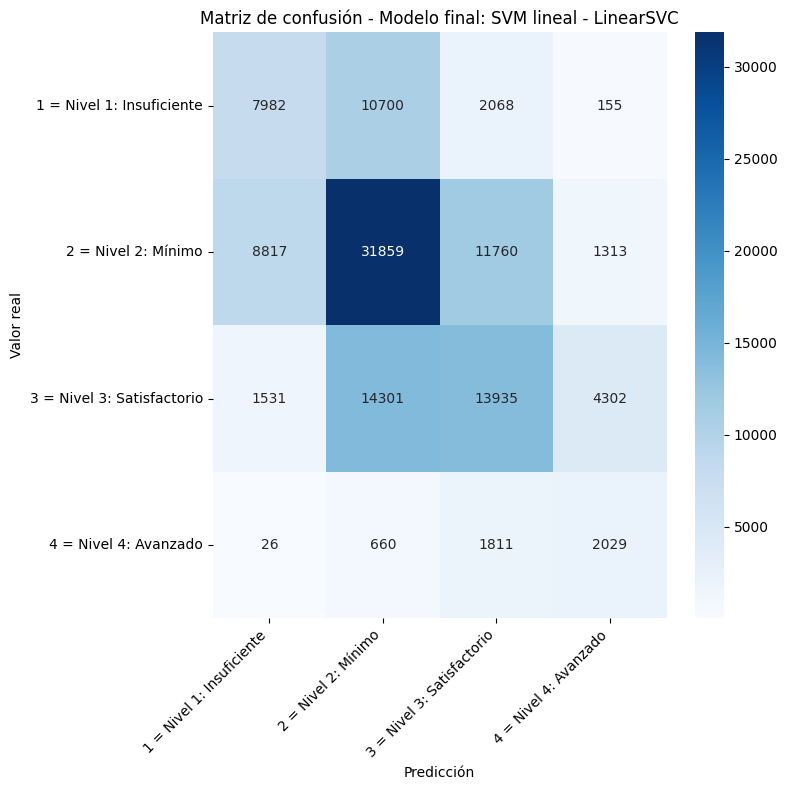

In [ ]:
# ============================================================
# 17.1 Matriz de confusión final en test
# ============================================================

clases_codificadas = TARGET_LABELS_CODIFICADOS
clases_nombres = [
    f"{codigo} = {TARGET_CODIGO_A_ETIQUETA[codigo]}"
    for codigo in clases_codificadas
]

cm_final = confusion_matrix(
    y_test,
    y_pred_final,
    labels=clases_codificadas
)

tam_fig = max(8, min(14, 0.8 * len(clases_codificadas)))
plt.figure(figsize=(tam_fig, tam_fig))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases_nombres,
    yticklabels=clases_nombres
)

plt.title(f"Matriz de confusión - Modelo final: {mejor_modelo_nombre}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 18. Verificación explícita del preprocesamiento en train + val y test

Aunque el `Pipeline` aplica automáticamente el preprocesamiento, esta celda verifica que el conjunto de test se transforma con el mismo pipeline ajustado en `train + val`. No se hace `fit` independiente sobre test.

In [ ]:
# ============================================================
# 18. Verificación explícita del preprocesamiento en train_val y test
# ============================================================

pipeline_preprocesamiento_final = Pipeline(
    steps=modelo_final.steps[:-1]
)

# IMPORTANTE:
# Esta transformación NO ajusta nada nuevo.
# Usa los parámetros aprendidos durante fit(X_train_val, y_train_val):
# - imputaciones,
# - categorías del OneHotEncoder,
# - mapeo del OrdinalEncoder,
# - parámetros del StandardScaler.
X_train_val_preprocesado = pipeline_preprocesamiento_final.transform(X_train_val)
X_test_preprocesado = pipeline_preprocesamiento_final.transform(X_test)

print("Verificación de preprocesamiento")
print("-" * 60)
print("X_train_val original:", X_train_val.shape)
print("X_train_val preprocesado:", X_train_val_preprocesado.shape)
print("X_test original:", X_test.shape)
print("X_test preprocesado:", X_test_preprocesado.shape)

assert X_train_val_preprocesado.shape[0] == X_train_val.shape[0], (
    "Error: el número de filas preprocesadas de train_val no coincide."
)

assert X_test_preprocesado.shape[0] == X_test.shape[0], (
    "Error: el número de filas preprocesadas de test no coincide."
)

assert X_train_val_preprocesado.shape[1] == X_test_preprocesado.shape[1], (
    "Error: train_val y test no tienen el mismo número de columnas después del preprocesamiento."
)

print("\nValidación correcta:")
print("El conjunto de test fue transformado con el mismo pipeline ajustado en train + val.")
print("No se realizó fit ni imputación independiente sobre X_test.")


Verificación de preprocesamiento
------------------------------------------------------------
X_train_val original: (452992, 16)
X_train_val preprocesado: (452992, 38)
X_test original: (113249, 16)
X_test preprocesado: (113249, 38)

Validación correcta:
El conjunto de test fue transformado con el mismo pipeline ajustado en train + val.
No se realizó fit ni imputación independiente sobre X_test.


## 19. Inspección de variables generadas por el preprocesamiento

Esta celda permite revisar cuántas variables quedan después de aplicar codificación ordinal, One-Hot Encoding y escalamiento.

In [ ]:
# ============================================================
# 19. Inspección de variables transformadas
# ============================================================

try:
    feature_names = modelo_final.named_steps["preprocessor"].get_feature_names_out()
    print("Cantidad de variables después del preprocesamiento:", len(feature_names))
    display(pd.DataFrame({"feature": feature_names}).head(80))
except Exception as e:
    print("No fue posible extraer los nombres de variables transformadas.")
    print("Detalle:", e)


Cantidad de variables después del preprocesamiento: 38


,feature
0,ordinal__fami_estratovivienda
1,ordinal__fami_educacionmadre
2,ordinal__fami_educacionpadre
3,ordinal__fami_cuartoshogar
4,ordinal__fami_personashogar
5,nominal__cole_bilingue_N
6,nominal__cole_bilingue_S
7,nominal__cole_calendario_A
8,nominal__cole_calendario_B
9,nominal__cole_calendario_OTRO


## 20. Guardar artefactos del modelo final

Se guardan el pipeline final, las métricas, los resultados de `GridSearchCV` y la información necesaria para reproducir la inferencia. El objeto guardado incluye el preprocesamiento, el clasificador y el mapeo del target codificado.

Este mapeo es indispensable porque el modelo trabaja con códigos numéricos `1..4`, pero la interpretación final debe volver a las etiquetas originales: `Nivel 1: Insuficiente`, `Nivel 2: Mínimo`, `Nivel 3: Satisfactorio` y `Nivel 4: Avanzado`.


In [ ]:
# ============================================================
# 20. Guardar modelo final y resultados
# ============================================================

if "metricas_finales_test" not in globals():
    raise RuntimeError(
        "Antes de guardar el modelo debes ejecutar la celda de métricas finales en test."
    )

slug_modelo = re.sub(r"[^a-zA-Z0-9]+", "_", mejor_modelo_nombre.lower()).strip("_")
MODEL_PATH = os.path.join(BASE_DIR, f"modelo_final_{slug_modelo}_pipeline.joblib")
RESULTADOS_VAL_PATH = os.path.join(BASE_DIR, "resultados_validacion_modelos_gridsearch.csv")
CV_RESULTS_PATH = os.path.join(BASE_DIR, "cv_results_gridsearch_detallado.csv")
METRICAS_TEST_PATH = os.path.join(BASE_DIR, "metricas_test_modelo_final.csv")
MAPEO_TARGET_PATH = os.path.join(BASE_DIR, "mapeo_target_labelencoder.csv")

artefacto_modelo = {
    "modelo": modelo_final,
    "mejor_modelo_nombre": mejor_modelo_nombre,
    "target_col": TARGET_COL,
    "target_label_encoder": target_label_encoder,
    "mapeo_target": mapeo_target,
    "target_labels_originales": TARGET_LABELS_ORIGINALES,
    "target_labels_codificados": TARGET_LABELS_CODIFICADOS,
    "target_codigo_a_etiqueta": TARGET_CODIGO_A_ETIQUETA,
    "target_etiqueta_a_codigo": TARGET_ETIQUETA_A_CODIGO,
    "columnas_entrenamiento": X_train_val.columns.tolist(),
    "metricas_validacion": resultados_gridsearch,
    "metricas_test": metricas_finales_test,
    "ordinal_cols": ordinal_cols,
    "nominal_cols": nominal_cols,
    "numeric_cols": numeric_cols,
    "columnas_eliminadas": columnas_existentes_a_eliminar,
    "columnas_sospechosas_leakage": columnas_sospechosas_leakage,
    "columnas_leakage_confirmadas": COLUMNAS_LEAKAGE_CONFIRMADAS,
    "id_cols_no_modelar": id_cols_no_modelar,
    "split_config": {
        "test_size": TEST_SIZE,
        "val_size": VAL_SIZE,
        "k_folds": K_FOLDS,
        "seed": SEED
    },
    "shape_X_train_original": X_train.shape,
    "shape_X_val_original": X_val.shape,
    "shape_X_test_original": X_test.shape,
    "shape_X_train_val_original": X_train_val.shape,
    "shape_X_train_val_preprocesado": X_train_val_preprocesado.shape,
    "shape_X_test_preprocesado": X_test_preprocesado.shape
}

joblib.dump(artefacto_modelo, MODEL_PATH)

resultados_gridsearch.to_csv(RESULTADOS_VAL_PATH, index=False, encoding="utf-8-sig")
metricas_finales_test.to_csv(METRICAS_TEST_PATH, index=False, encoding="utf-8-sig")
mapeo_target.to_csv(MAPEO_TARGET_PATH, index=False, encoding="utf-8-sig")

if not cv_results_todos.empty:
    cv_results_todos.to_csv(CV_RESULTS_PATH, index=False, encoding="utf-8-sig")

print("Artefactos guardados correctamente.")
print("Modelo final:", MODEL_PATH)
print("Resultados validación:", RESULTADOS_VAL_PATH)
print("Métricas test:", METRICAS_TEST_PATH)
print("Mapeo target:", MAPEO_TARGET_PATH)
if not cv_results_todos.empty:
    print("CV results detallado:", CV_RESULTS_PATH)

display(metricas_finales_test)


Artefactos guardados correctamente.
Modelo final: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/modelo_final_svm_lineal_linearsvc_pipeline.joblib
Resultados validación: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/resultados_validacion_modelos_gridsearch.csv
Métricas test: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/metricas_test_modelo_final.csv
Mapeo target: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/mapeo_target_labelencoder.csv
CV results detallado: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/cv_results_gridsearch_detallado.csv


,modelo_final,dataset_evaluacion,accuracy,f1_macro,f1_weighted,n_train_val,n_test
0,SVM lineal - LinearSVC,test,0.492764,0.436605,0.491738,452992,113249


## 21. Ejemplo de inferencia con nuevos datos

Para clasificar nuevos registros, se debe entregar un `DataFrame` con la misma estructura de variables usada durante el entrenamiento. El pipeline guardado se encarga de aplicar el preprocesamiento y luego generar la predicción.

In [ ]:
# ============================================================
# 21. Ejemplo de inferencia
# ============================================================

n_ejemplo = min(5, len(X_test))

nuevos_datos = X_test.head(n_ejemplo).copy()

predicciones_codificadas = pd.Series(
    modelo_final.predict(nuevos_datos),
    index=nuevos_datos.index,
    name="prediccion_codificada"
).astype(int)

resultado_inferencia = nuevos_datos.copy()
resultado_inferencia["prediccion_codificada"] = predicciones_codificadas
resultado_inferencia["prediccion_etiqueta"] = decodificar_target(predicciones_codificadas)

# Esta columna ayuda a verificar que el código numérico coincide con el número del nivel.
resultado_inferencia["prediccion_nivel"] = resultado_inferencia["prediccion_codificada"]

display(resultado_inferencia)


,estu_tipodocumento,cole_bilingue,cole_calendario,cole_caracter,cole_genero,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,estu_genero,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tienecomputador,fami_tieneinternet,prediccion_codificada,prediccion_etiqueta,prediccion_nivel
455741,TI,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,CALI,OFICIAL,F,Cinco,Educación profesional incompleta,No sabe,Estrato 2,5 a 6,Si,Si,2,Nivel 2: Mínimo,2
535232,CC,N,A,ACADÉMICO,MIXTO,SABATINA,MEDELLÍN,NO OFICIAL,F,Dos,Primaria incompleta,Primaria incompleta,Estrato 2,5 a 6,No,No,1,Nivel 1: Insuficiente,1
55133,TI,NaN,A,ACADÉMICO,MIXTO,COMPLETA,SOACHA,NO OFICIAL,M,Tres,No sabe,No sabe,Estrato 3,3 a 4,Si,Si,3,Nivel 3: Satisfactorio,3
11946,TI,NaN,B,ACADÉMICO,MIXTO,MAÑANA,CALI,NO OFICIAL,M,Tres,Técnica o tecnológica incompleta,Educación profesional completa,Estrato 4,3 a 4,Si,Si,4,Nivel 4: Avanzado,4
414565,TI,N,A,TÉCNICO/ACADÉMICO,MIXTO,UNICA,BARRANCABERMEJA,OFICIAL,M,Uno,No sabe,No sabe,Estrato 2,1 a 2,No,Si,2,Nivel 2: Mínimo,2


## 22. Conclusión metodológica

El flujo construido fortalece la etapa posterior al baseline porque:

- Separa los datos en `train`, `val` y `test`, evitando usar el conjunto de prueba durante la selección del modelo.
- Codifica el target de forma numérica antes del split, con un mapeo único y verificable: `Nivel 1 -> 1`, `Nivel 2 -> 2`, `Nivel 3 -> 3` y `Nivel 4 -> 4`.
- Mantiene la coherencia de esa codificación en `train`, `val`, `test`, `GridSearchCV`, evaluación final e inferencia.
- Mantiene el preprocesamiento de variables predictoras dentro del `Pipeline`, por lo que imputación, codificación y escalamiento se aprenden solo con los datos permitidos en cada etapa.
- Usa `GridSearchCV` con `StratifiedKFold` de 5 folds para comparar hiperparámetros dentro de cada familia de modelos.
- Evalúa KNN, SVM lineal, árbol de decisión, Random Forest, CatBoost y XGBoost bajo el mismo flujo de preprocesamiento.
- Selecciona el mejor modelo usando `F1 macro` en validación, una métrica pertinente para clasificación multiclase.
- Reentrena el modelo seleccionado con `train + val` y evalúa una sola vez sobre `test`.
- Guarda el pipeline completo como artefacto reproducible con `joblib`, incluyendo métricas, columnas usadas, configuración de split, resultados de la búsqueda y mapeo del target.

Con esto se evita el principal riesgo metodológico: que información del conjunto de validación o prueba influya en el aprendizaje de imputadores, codificadores, escaladores, hiperparámetros o parámetros finales del modelo. También se evita que los modelos reciban etiquetas textuales como target, lo cual reduce errores de compatibilidad y mantiene trazabilidad en la interpretación de resultados.
